In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import jensenshannon

In [2]:
df_historical = pd.read_csv('../../data/processed/dataset_14-23.csv')
rnn_model = pd.read_csv('../probabilistic/new_trained_results/rnn_1423_weights.csv')

## Historical Data

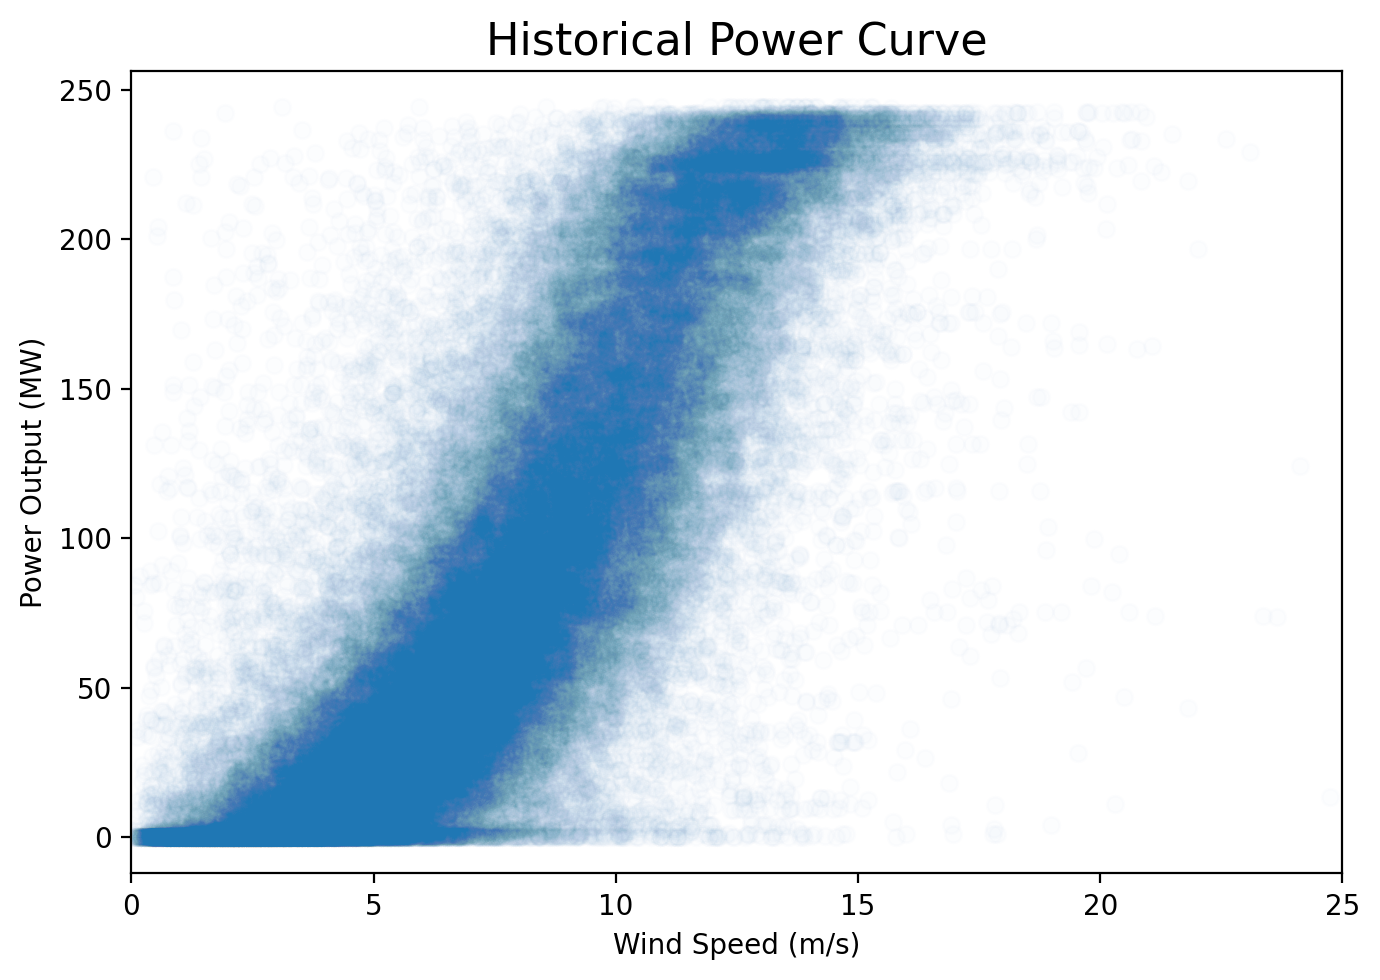

In [3]:
# power curve
plt.figure(figsize=(7, 5), dpi=200)
plt.scatter(df_historical['speed'], df_historical['power'], alpha=0.01)
plt.title('Historical Power Curve', fontsize=16)
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power Output (MW)')
plt.xlim(0, 25)
plt.tight_layout()

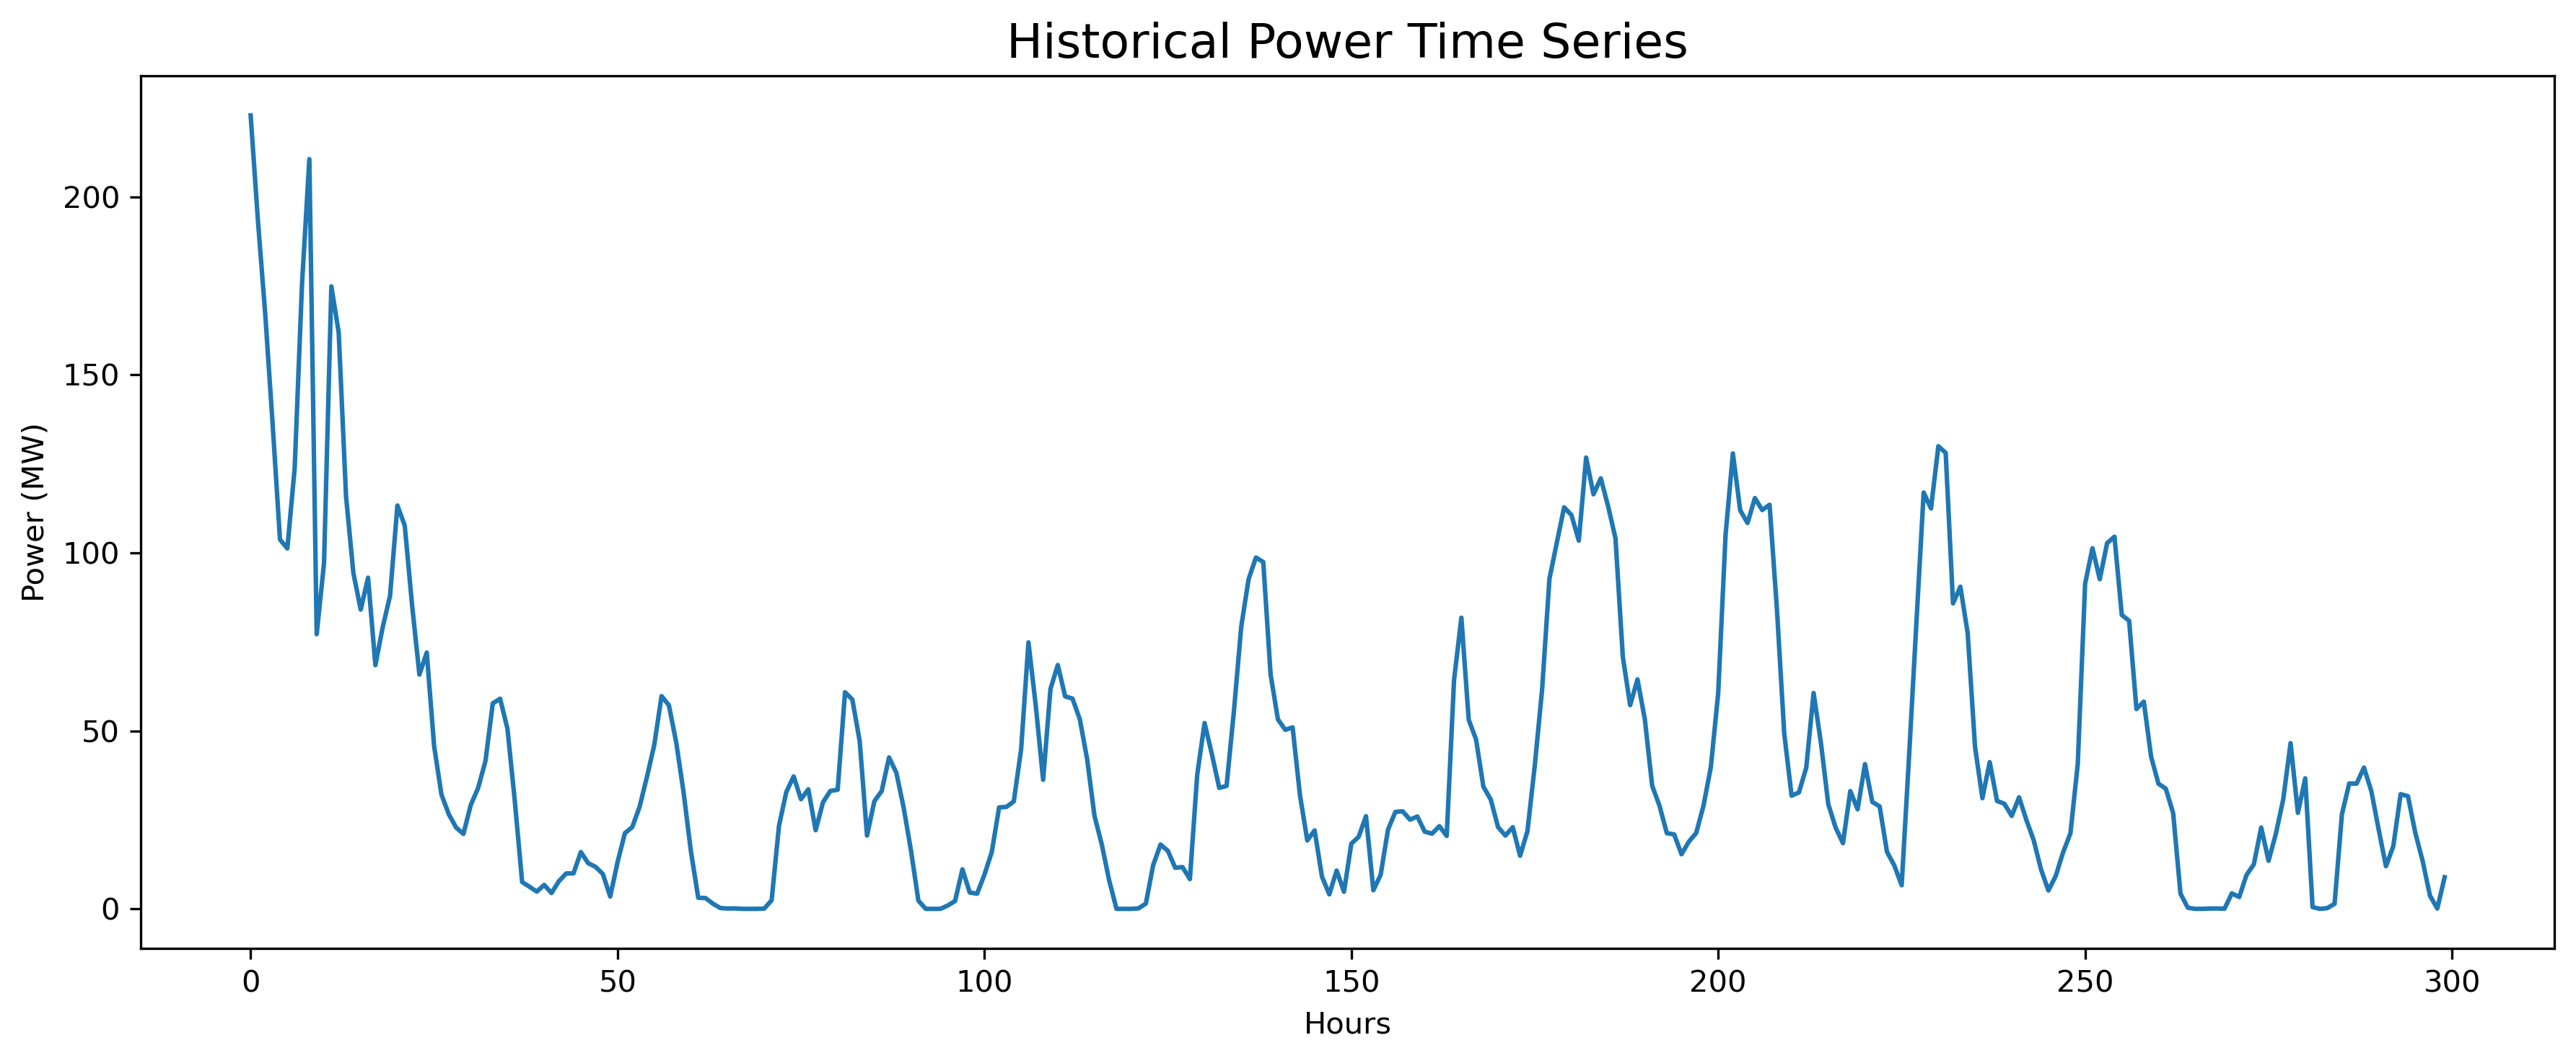

In [4]:
# time series
plt.figure(figsize=(12, 5), dpi=300)
plt.plot(df_historical['power'][:300].reset_index(drop=True))
plt.title('Historical Power Time Series', fontsize=16)
plt.xlabel('Hours')
plt.ylabel('Power (MW)')
plt.tight_layout()

## Historical + Model Predictions

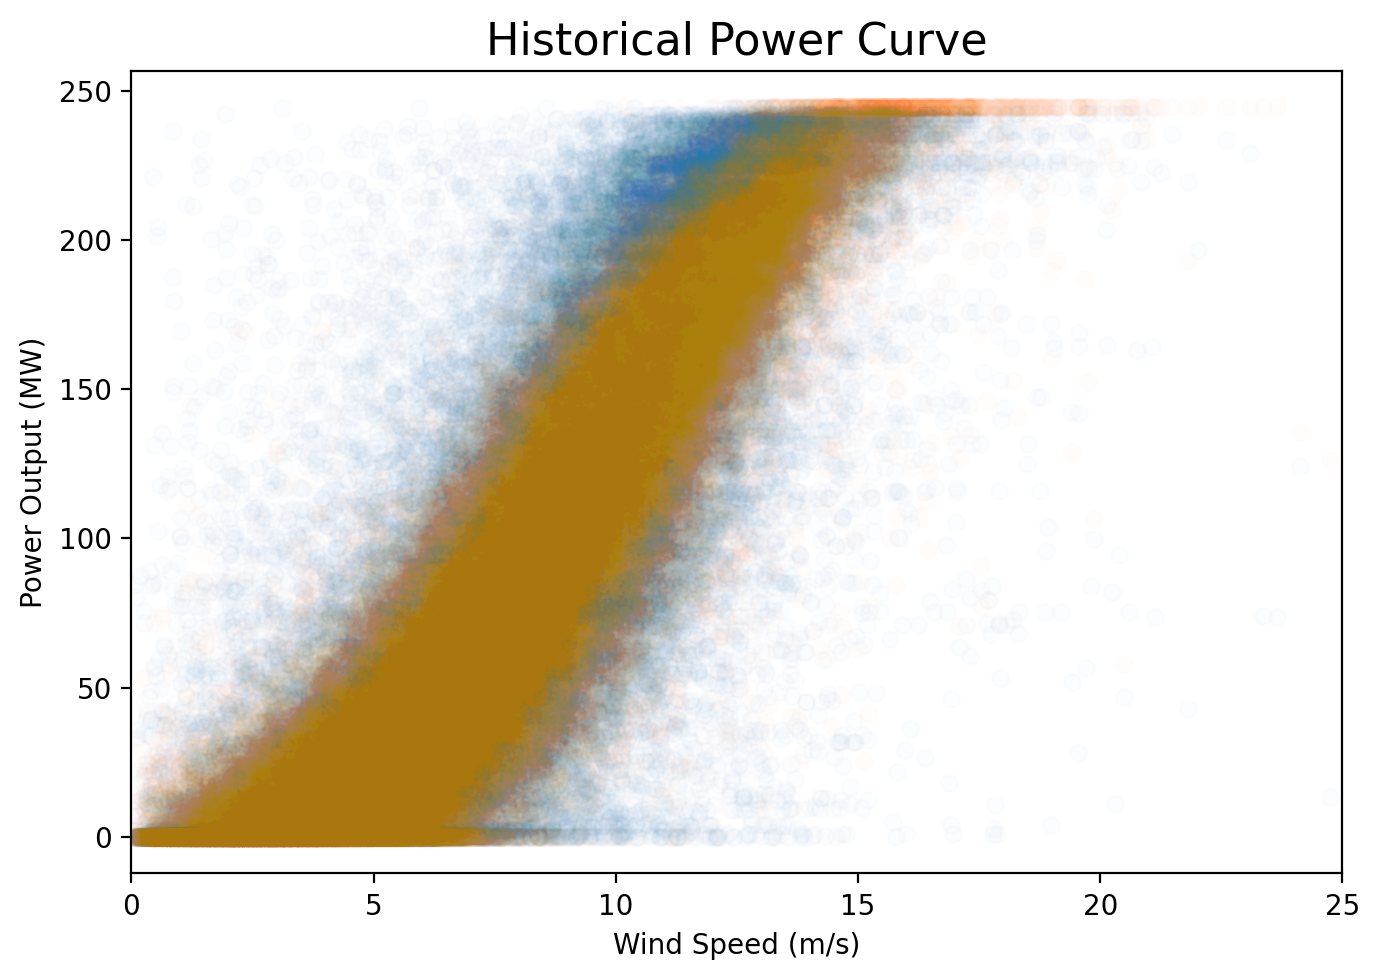

In [5]:
# power curve comparison

plt.figure(figsize=(7, 5), dpi=200)
plt.scatter(df_historical['speed'], df_historical['power'], alpha=0.01)
plt.scatter(rnn_model['speed'], rnn_model['preds'], alpha=0.01)
plt.title('Historical Power Curve', fontsize=16)
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power Output (MW)')
plt.xlim(0, 25)
plt.tight_layout()

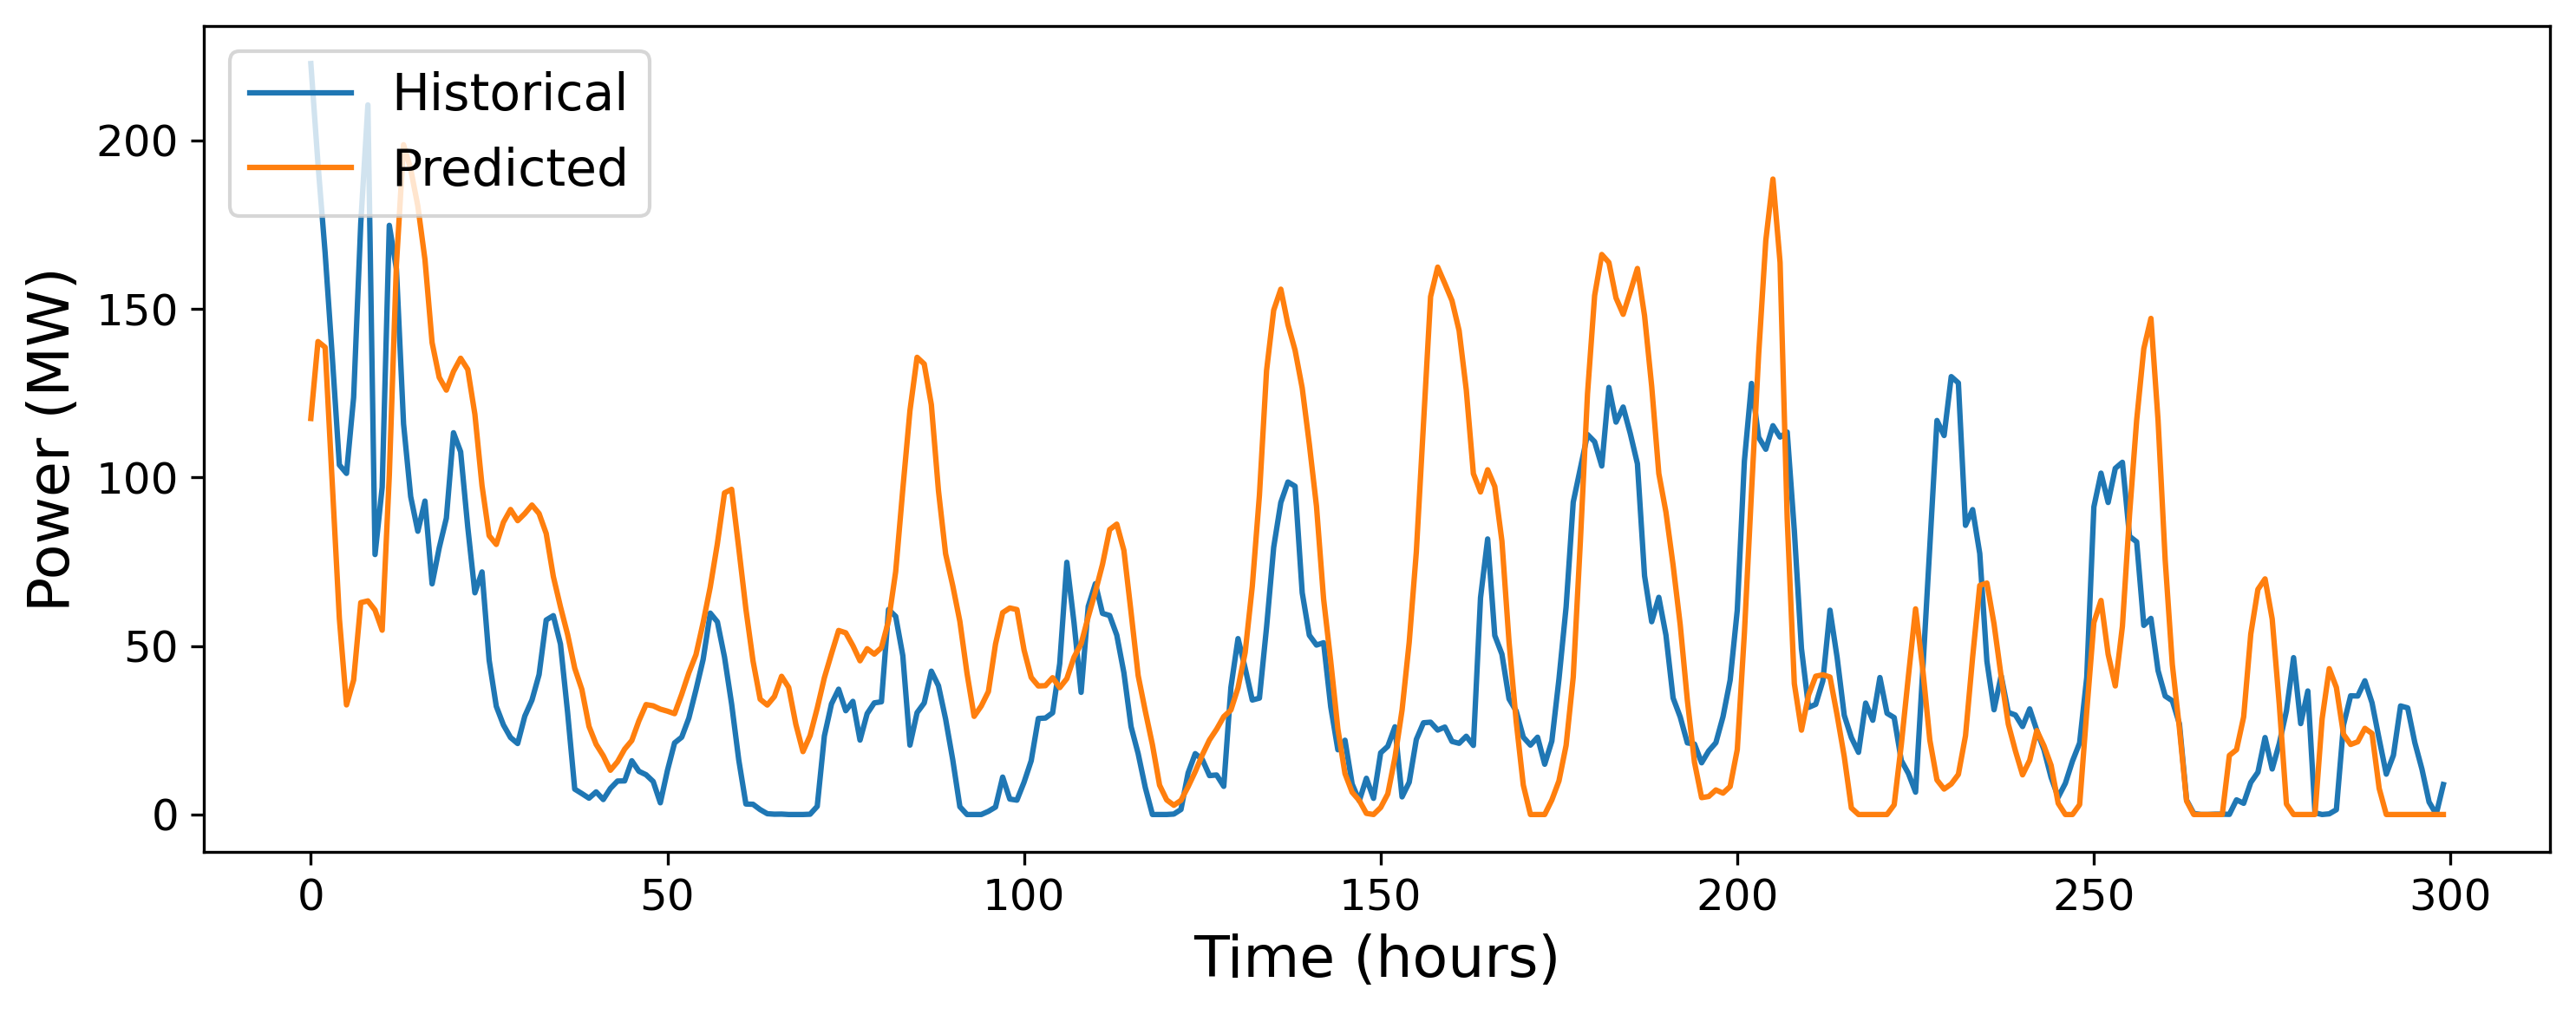

In [6]:
# time series comparison

plt.figure(figsize=(10, 4), dpi=300)
# plot first 300 hours
plt.plot(df_historical['power'][:300].reset_index(drop=True), label='Historical')
plt.plot(rnn_model['preds'][:300].reset_index(drop=True), label='Predicted')
plt.xlabel('Time (hours)', fontsize=16)
plt.ylabel('Power (MW)', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc='upper left', fontsize=14)
plt.tight_layout()

#### Power curve density plots

In [7]:
# power curve density
H_true, _, _ = np.histogram2d(df_historical['speed'], df_historical['power'], bins=50)
H_pred, _, _ = np.histogram2d(rnn_model['speed'], rnn_model['preds'], bins=50)
H_true_norm = H_true / H_true.sum()
H_pred_norm = H_pred / H_pred.sum()
js_div = jensenshannon(H_true_norm.flatten(), H_pred_norm.flatten())  # Value between 0 and 1
similarity = 1 - js_div
match_percentage = np.round(similarity * 100, 2)

# log transform
vals_true = np.log(H_true.T)
vals_true[np.isneginf(vals_true)] = 0
vals_true = vals_true / vals_true.max()
vals_pred = np.log(H_pred.T)
vals_pred[np.isneginf(vals_pred)] = 0
vals_pred = vals_pred / vals_pred.max()
diff = vals_pred - vals_true

/var/folders/ld/ry50f5bs3tzgqgpbq7z2_6pw0000gn/T/ipykernel_79921/4098236000.py:11: RuntimeWarning: divide by zero encountered in log
  vals_true = np.log(H_true.T)
/var/folders/ld/ry50f5bs3tzgqgpbq7z2_6pw0000gn/T/ipykernel_79921/4098236000.py:14: RuntimeWarning: divide by zero encountered in log
  vals_pred = np.log(H_pred.T)


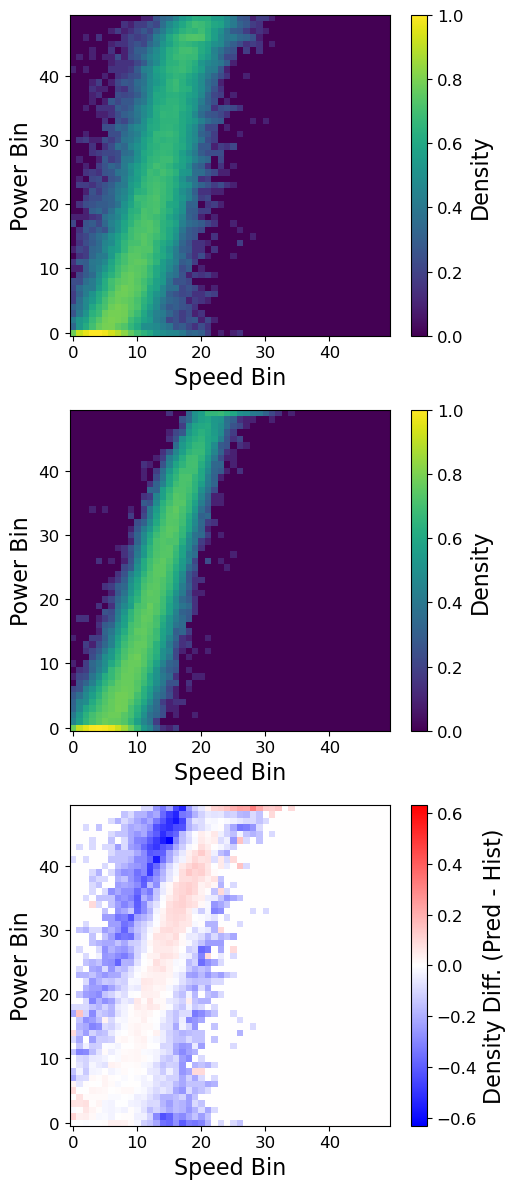

In [8]:
# 3 power density plots
fig, axs = plt.subplots(3, 1, figsize=(5, 12))

# historical density plot
im0 = axs[0].imshow(vals_true, origin='lower', cmap='viridis')
axs[0].set_xlabel("Speed Bin", fontsize=16)
axs[0].set_ylabel("Power Bin", fontsize=16)
axs[0].tick_params(axis='both', which='major', labelsize=12)

# predicted density plot
im1 = axs[1].imshow(vals_pred, origin='lower', cmap='viridis')
axs[1].set_xlabel("Speed Bin", fontsize=16)
axs[1].set_ylabel("Power Bin", fontsize=16)
axs[1].tick_params(axis='both', which='major', labelsize=12)

# difference density plot (predicted - historical)
im2 = axs[2].imshow(diff, origin='lower', cmap='bwr', vmin=-np.max(np.abs(diff)), vmax=np.max(np.abs(diff)))
axs[2].set_xlabel("Speed Bin", fontsize=16)
axs[2].set_ylabel("Power Bin", fontsize=16)
axs[2].tick_params(axis='both', which='major', labelsize=12)

# setting up colorbars
cbar0 = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cbar0.set_label('Density', fontsize=16)
cbar0.ax.tick_params(labelsize=12)

cbar1 = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cbar1.set_label('Density', fontsize=16)
cbar1.ax.tick_params(labelsize=12)

cbar2 = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cbar2.set_label("Density Diff. (Pred - Hist)", fontsize=16)
cbar2.ax.tick_params(labelsize=12)

plt.tight_layout()